# **2D Instance Segmentation pipeline**
___  

In this notebook, we demonstrate the use of the [BiaPy](https://biapyx.github.io/) pipeline for **2D instance segmentation** of microscopy data.

<figure>
<center>
<img src='https://biapy.readthedocs.io/en/latest/_images/mitoem_crop.png' width='300px'/>
<img src='https://biapy.readthedocs.io/en/latest/_images/mitoem_crop_mask.png' width='300px'/>
<figcaption><b>Figure 1</b>: Example of a 2D instance segmentation problem. From left to right: 2D electron microscopy image and its corresponding mitochondria instance labels.</figcaption>
</center>
</figure>

Without any coding, we'll guide you step-by-step through the process to:
1. **Upload a set of training and test images** along with their corresponding instance label images.
2. **Train a Deep Neural Network (DNN)** model using the training set.
3. **Apply the model** to the test images.
4. **Download the segmentation results** to your local machine.

**Disclaimer:** The structure of the notebook is heavily inspired by the fantastic [ZeroCostDL4Mic notebooks](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

**Contact:** This notebook was created by [Ignacio Arganda-Carreras](mailto:ignacio.arganda@ehu.eus), [Lenka Backová](mailto:lenka.backova@ehu.eus), [Daniel Franco-Barranco](mailto:daniel.franco@dipc.org) and [Ane Paniagua](mailto:anepaniagua@gmail.com). For suggestions, comments, or issues, please reach out to us via email or [create an issue in BiaPy's repository](https://github.com/BiaPyX/BiaPy/issues). Thank you!


## **Expected inputs and outputs**
___
**Inputs**

This notebook expects five folders as input:
* **Training raw images**: with the raw 2D images to train the model.
* **Training label images**: with the instance-label 2D images to train the model. Their number and sizes must match those of the training raw images.
* **Test raw images**: with the raw 2D images to test the model.
* **Test label images** (optional): with the instance-label 2D images to test the model. Their number and sizes must match those of the validation raw images.
* **Output folder**: a path to store the segmentation results.

**Outputs**

Upon successful execution, a new folder will be generated containing one result **TIFF image** for every test image. These result images will showcase the instances of the objects of interest as determined by our pipeline.

<font color='red'><b>Note:</b></font> For testing, this notebook can be executed using the **example datasets found under 'Manage file(s) source > Option 3'**.

**Data structure**

To ensure the proper operation of the library the data directory tree should be something like this:

```
dataset/
├── train
│   ├── raw
│   │   ├── training-0001.tif
│   │   ├── training-0002.tif
│   │   ├── . . .
│   │   └── training-9999.tif
│   └── label
│       ├── training_groundtruth-0001.tif
│       ├── training_groundtruth-0002.tif
│       ├── . . .
│       └── training_groundtruth-9999.tif
└── test
    ├── raw
    │   ├── testing-0001.tif
    │   ├── testing-0002.tif
    │   ├── . . .
    │   └── testing-9999.tif
    └── label
        ├── testing_groundtruth-0001.tif
        ├── testing_groundtruth-0002.tif
        ├── . . .
        └── testing_groundtruth-9999.tif
```

**⚠️ Warning:** Ensure that images and their corresponding masks are sorted in the same way. A common approach is to fill with zeros the image number added to the filenames (as in the example).

**Input Format Support**

This notebook is compatible with a range of input formats. You can use the following file extensions: `.tif`, `.png`, `.jpg`, `.npy`, `.h5`, `.hdf5` (every extension supported by [scikit-image](https://scikit-image.org/docs/stable/api/skimage.io.html#skimage.io.imread)).

## **Check for GPU Access**

In [2]:
import torch
torch.cuda.is_available()

True

## **Import all dependencies**

In [1]:
import os
import sys
import numpy as np
from tqdm.notebook import tqdm
from skimage.io import imread
import ipywidgets as widgets
from ipywidgets import Output
from biapy import BiaPy

## **Download the data**

In [12]:
import os

import gdown

os.chdir("/home/mpaul2")

gdown.download("https://drive.google.com/uc?id=1b7_WDDGEEaEoIpO_1EefVr0w0VQaetmg", "Stardist_v2.zip", quiet=True)

!mkdir stardist
!unzip -q Stardist_v2.zip -d stardist/
!rm Stardist_v2.zip

print( 'Dataset downloaded and unzipped under /content/data')

Dataset downloaded and unzipped under /content/data


## **Paths for Input Images and Output Files**

In [3]:
train_data_path = 'stardist/data/train/raw'
train_data_gt_path = 'stardist/data/train/label' 

test_data_path = 'stardist/data/test/raw' 
test_data_gt_path = 'stardist/data/test/label' 
output_path = 'stardist/output' 

import os
from pathlib import Path

def count_image_files(directory):
    if not directory or not os.path.exists(directory):
        return 0
    image_extensions = {'.jpg', '.jpeg', '.png', '.tif', '.npy', '.tiff', '.h5', '.hd5', '.zarr'}
    count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if Path(file).suffix.lower() in image_extensions:
                count += 1
    return count

num_train_images = count_image_files(train_data_path)
num_train_labels = count_image_files(train_data_gt_path)

num_test_images = count_image_files(test_data_path)
num_test_labels = count_image_files(test_data_gt_path)

print(f"Number of training raw images: {num_train_images}")
print(f"Number of training label images: {num_train_labels}")
print(f"Number of test raw images: {num_test_images}")
if test_data_gt_path != "":
    print(f"Number of test label images: {num_test_labels}")

if num_train_images != num_train_labels:
    print("Error: The number of training raw images does not match the number of training label images.")
if test_data_gt_path != "" and num_test_images != num_test_labels:
    print("Error: The number of test raw images does not match the number of test label images.")

Number of training raw images: 45
Number of training label images: 45
Number of test raw images: 2
Number of test label images: 2


In [ ]:
## **Dataset Visualization**
---

In [4]:
%matplotlib inline
import matplotlib
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
import os
from ipywidgets import interact, IntSlider, Layout, Dropdown, HBox, Output

# Initialize paths and image IDs
input_path = train_data_path
gt_path = train_data_gt_path

ids_input = sorted(next(os.walk(input_path))[2])
ids_gt = sorted(next(os.walk(gt_path))[2])

# Create random color map
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gist_rainbow(vals))
cmap.colors[0] = [0., 0., 0., 1.] # set background to black

# Dropdown widget to choose training or test set
dropdown = Dropdown(
    options=['training-set', 'test-set'],
    value='training-set',
    description='Set:',
    disabled=False,
)

# Slider widget to choose instance
slider= IntSlider(
    value=0,
    min=1,
    max=len(ids_input),
    step=1,
    description='Image index:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    layout=Layout(width='500px', margin = '0 0 0 10px')
)

slider.style.description_width = 'initial'
slider.style.handle_color='blue'

# Initialize Output instance to handle code output cell
output = Output()

# Function to display images depending on slider value
def display_images(change):
    with output:
        output.clear_output(wait=True)
        index = change['new']

        global input_path, ids_input, input_img
        input_img_path = os.path.join(input_path, ids_input[index-1])
        input_img = imread(input_img_path)

        # # Print sample path to ensure the image displayed is correct
        # print(input_img_path)

        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.title(f"Raw image: {index}")
        plt.imshow(input_img, cmap='magma', vmin=np.percentile(input_img,0.1),vmax=np.percentile(input_img,99.9))
        # plt.axis('off')

        global gt_path, ids_gt, gt_img
        if ids_gt != []: # If StopIteration exception was not thrown
            gt_img_path = os.path.join(gt_path, ids_gt[index-1])
            gt_img = imread(gt_img_path).astype(np.uint16)
            plt.subplot(1, 2, 2)
            plt.title("Label image")
            plt.imshow(gt_img,  cmap=cmap, interpolation='nearest')
            # plt.axis('off')

            # # Print label path to ensure the image displayed is correct
            # print(gt_img_path)

        else:
            print("No labels for this set.")

        # print(f"Instance path: {input_img_path}")
        # print(f"Label path: {gt_img_path}")

        plt.show()

# Function to update paths and image IDs (input_path, ids_input, gt_path, ids_gt)
def update_paths(change):
    global input_path, gt_path
    if change.new == 'test-set':
        input_path = test_data_path
        gt_path = test_data_gt_path
    else:
        input_path = train_data_path
        gt_path = train_data_gt_path

    global ids_input, ids_gt
    ids_input = sorted(next(os.walk(input_path))[2])
    try:
        ids_gt = sorted(next(os.walk(gt_path))[2])
    except StopIteration:
        ids_gt = []

    # Reset slider value when dropdown changes
    slider.value = 1
    slider.max = len(ids_input)
    display_images({'new': 1})

# Create an HBox to hold the dropdown and slider
controls = HBox([dropdown, slider])
display(controls, output)

# Link widgets to functions
slider.observe(display_images, names='value')
dropdown.observe(update_paths, names='value')

# Initial display
display_images({'new': slider.value})

Output()

## **Configure and Train the DNN Model**
---


### **Select your parameters**
---
#### **Name of the model**
* **`model_name`:** Use only my_model -style, not my-model (Use "_" not "-"). Do not use spaces in the name. Avoid using the name of an existing model (saved in the same folder) as it will be overwritten.

#### **Data management**
* **`percentage_validation`:**  Input the percentage of your training dataset you want to use to validate the network during the training. **Default value: 10**

* **`test_ground_truth`:** Select to use test data ground truth to measure the performance of the model's result. If selected, **test_data_gt_path** variable path set above will be used. **Default value: True**

#### **Basic training parameters**
* **`input_channels`:** Input the number of channels of your images (grayscale = 1, RGB = 3). **Default value: 1**

* **`number_of_epochs`:** Input how many epochs (rounds) the network will be trained. For the example dataset, reasonable results can already be observed after 100 epochs. **Default value: 100**

* **`patience`:**  Input how many epochs you want to wait without the model improving its results in the validation set to stop training. **Default value: 20**

#### **Advanced Parameters - experienced users only**
* **`model_architecture`:** Select the architecture of the DNN used as backbone of the pipeline. Options: U-Net, Residual U-Net, Attention U-Net, SEUNet, MultiResUNet, ResUNet++ (see [Franco-Barranco et al., 2021](https://link.springer.com/article/10.1007/s12021-021-09556-1)), UNETR-Mini, UNETR-Small, UNETR-Base and U-NeXt V1.  **Default value: U-Net**

* **`batch_size:`** This parameter defines the number of patches seen in each training step. Reducing or increasing the **batch size** may slow or speed up your training, respectively, and can influence network performance. **Default value: 8**

* **`patch_size`:** Input the size of the patches use to train your model (length in pixels in X and Y). The value should be smaller or equal to the dimensions of the image. **Default value: 256**

* **`optimizer`:** Select the optimizer used to train your model. Options: ADAM, ADAMW, Stochastic Gradient Descent (SGD). ADAM usually converges faster, while ADAMW provides a balance between fast convergence and better handling of weight decay regularization. SGD is known for better generalization.**Default value: ADAMW**

* **`initial_learning_rate`:** Input the initial value to be used as learning rate. If you select ADAM or ADAMW as optimizer, this value should be around 10e-4. **Default value: 0.0001**

* **`learning_rate_scheduler`:** Select to adjust the learning rate between epochs. Options: "None", "Reduce on plateau", "One cycle", "Warm-up cosine decay". **Default value: None**

* **`problem_representation`:** Select the type of representation that the model must learn to identify the instances. Options: "Binary mask + Contours", "Binary mask + Central points", "Binary mask + Contours + Distance map", "Binary mask + Contours + Foreground mask" (see <a href="https://link.springer.com/chapter/10.1007/978-3-030-59722-1_7">Wei et al. 2020</a>). **Default value: "Binary mask + Contours"**

* **`aggressive_data_augmentation`:** Select to apply more aggressive data augmentation (CutBlur, CutNoise, GridMask, etc.) during training. Otherwise, simple flips and rotations will be applied. **Default value: False**

* **`test_time_augmentation`:** Select to apply augmentation (flips and rotations) at test time. It usually provides more robust results but uses more time to produce each result. **Default value: False**

In [5]:
#@markdown ###Name of the model:
model_name = "my_2d_instance_segmentation" #@param {type:"string"}

#@markdown ### Data management:
test_ground_truth = True #@param {type:"boolean"}
percentage_validation =  10 #@param {type:"number"}

#@markdown ### Basic training parameters:
input_channels = 1 #@param {type:"number"}
number_of_epochs =  100#@param {type:"number"}
patience =  20#@param {type:"number"}

#@markdown ### Advanced training parameters:

model_architecture = "U-Net" #@param ["U-Net", "Residual U-Net", "Attention U-Net", 'MultiResUNet', 'ResUNet++', 'SEUNet', "UNETR-Mini","UNETR-Small", "UNETR-Base", "U-NeXt V1"]
batch_size =  8#@param {type:"number"}
patch_size = 256 #@param {type:"number"}
optimizer = "ADAMW" #@param ["ADAM", "SGD","ADAMW"]
initial_learning_rate = 0.0001 #@param {type:"number"}
problem_representation = "Binary mask + Contours" #@param ["Binary mask + Contours", "Binary mask + Central points", "Binary mask + Distance map","Binary mask + Contours + Distance map", "Binary mask + Contours + Foreground mask", "Binary mask + Contours + Distance map with background", "Distance map with background"]
learning_rate_scheduler = "None" #@param ["None", "Reduce on plateau","One cycle", "Warm-up cosine decay"]
aggressive_data_augmentation = False #@param {type:"boolean"}
test_time_augmentation = False #@param {type:"boolean"}

checkpoint_path = ''

In [6]:
import os
import errno
from biapy import BiaPy

job_name = model_name

yaml_file = "stardist/"+str(job_name)+".yaml"

# remove previous configuration file if it exists with the same name
if os.path.exists( yaml_file ):
    os.remove( yaml_file )

# remove template file it is exists
template_file = '2d_instance_segmentation.yaml'

if os.path.exists( template_file ):
    os.remove( template_file )

# Download template file
import shutil
!wget -P stardist/ https://raw.githubusercontent.com/BiaPyX/BiaPy/master/templates/instance_segmentation/2d_instance_segmentation.yaml &> /dev/null


### **Train the model**
---

In [8]:
if not os.path.exists(train_data_path):
    raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), train_data_path)
ids = sorted(next(os.walk(train_data_path))[2])
if len(ids) == 0:
    raise ValueError("No images found in dir {}".format(train_data_path))
if not os.path.exists(train_data_gt_path):
    raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), train_data_gt_path)
ids = sorted(next(os.walk(train_data_gt_path))[2])
if len(ids) == 0:
    raise ValueError("No images found in dir {}".format(train_data_gt_path))

# Check folders before modifying the .yaml file
if not os.path.exists(test_data_path):
    raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), test_data_path)
ids = sorted(next(os.walk(test_data_path))[2])
if len(ids) == 0:
    raise ValueError("No images found in dir {}".format(test_data_path))
if test_ground_truth:
    if not os.path.exists(test_data_gt_path):
        raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), test_data_gt_path)
    ids = sorted(next(os.walk(test_data_gt_path))[2])
    if len(ids) == 0:
        raise ValueError("No images found in dir {}".format(test_data_gt_path))

# open template configuration file
import yaml
with open( 'stardist/2d_instance_segmentation.yaml', 'r') as stream:
    try:
        biapy_config = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

# update paths to data
biapy_config['DATA'] = {}
biapy_config['DATA']['TRAIN'] = {}
biapy_config['DATA']['TRAIN'] ['PATH']= {}
biapy_config['DATA']['TEST'] = {}
biapy_config['DATA']['TEST']['PATH'] = {}
biapy_config['DATA']['TRAIN']['PATH'] = train_data_path
biapy_config['DATA']['TRAIN']['GT_PATH'] = train_data_gt_path
biapy_config['DATA']['TEST']['PATH'] = test_data_path
biapy_config['DATA']['TEST']['GT_PATH'] = test_data_gt_path

# update data patch size
biapy_config['DATA']['PATCH_SIZE'] = '('+str(patch_size)+', '+ str(patch_size)+', ' + str(input_channels)+')'
# adjust test padding accordingly
padding = patch_size // 8
biapy_config['DATA']['TEST']['PADDING'] = '('+str(padding)+', '+ str(padding)+')'

# update training parameters
biapy_config['DATA']['VAL'] = {}
biapy_config['DATA']['VAL']['FROM_TRAIN'] = True
biapy_config['DATA']['VAL']['SPLIT_TRAIN'] = percentage_validation/100.0
biapy_config['TRAIN']={}
biapy_config['TRAIN']['EPOCHS'] = number_of_epochs
if number_of_epochs < 10:
    biapy_config['LOG'] = {}
    biapy_config['LOG']['CHART_CREATION_FREQ'] = 1
biapy_config['TRAIN']['PATIENCE'] = patience
biapy_config['TRAIN']['BATCH_SIZE'] = batch_size
biapy_config['TRAIN']['OPTIMIZER'] = optimizer
biapy_config['TRAIN']['LR'] = initial_learning_rate
biapy_config['TRAIN']['ENABLE'] = True
biapy_config['TRAIN']['VERBOSE'] = True
# change source to build model - biapy, torchvision or bmz
#if changed_source:
#    if source.value == "BiaPy":
#        biapy_config['MODEL']['SOURCE'] = "biapy"
#    elif source.value == 'Torchvision':
#        biapy_config['MODEL']['SOURCE'] = "torchvision"
#        biapy_config['MODEL']['TORCHVISION_MODEL_NAME'] = t_vision.value
#    elif source.value == 'BioImage Model Zoo':
#        biapy_config['MODEL']['SOURCE'] = "bmz"
#        biapy_config['MODEL']['BMZ'] = {}
#        biapy_config['MODEL']['BMZ']['SOURCE_MODEL_ID'] = str(bmz.value).strip()
#else:
biapy_config['MODEL']['SOURCE'] = "biapy"

# Transcribe problem representation
#   BC = "Binary mask + Contours"
#   BCM = "Binary mask + Contours + Foreground mask"
#   BCD = "Binary mask + Contours + Distance map"
#   BCDv2 = "Binary mask + Contours + Distance map with background"
#   Dv2 = "Distance map with background"
#   BDv2 = "Binary mask + Distance map with background"
#   BP = "Binary mask + Central points"
#   BD = "Binary mask + Distance map"
problem_channels = 'BC'
if problem_representation == "Binary mask + Contours":
    problem_channels = 'BC'
elif problem_representation == "Binary mask + Central points":
    problem_channels = 'BP'
elif problem_representation == "Binary mask + Distance map":
    problem_channels = 'BD'
elif problem_representation == "Binary mask + Contours + Foreground mask":
    problem_channels = 'BCM'
elif problem_representation == "Binary mask + Contours + Distance map":
    problem_channels = 'BCD'
elif problem_representation == "Binary mask + Contours + Distance map with background":
    problem_channels = 'BCDv2'
elif problem_representation == "Distance map with background":
    problem_channels = 'Dv2'
else:
    problem_channels = 'BDv2'

biapy_config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = problem_channels
biapy_config['PROBLEM']['INSTANCE_SEG']['DATA_MW_TH_TYPE'] = "auto"

# Transcribe model architecture
# Available models: "U-Net", "Residual U-Net", "Attention U-Net",
# 'MultiResUNet', 'SEUNet', 'ResUNet++', "UNETR-Mini","UNETR-Small"
# "UNETR-Base"
architecture = 'unet'
if model_architecture == "U-Net":
    architecture = 'unet'
elif model_architecture == "Residual U-Net":
    architecture = 'resunet'
elif model_architecture == "Attention U-Net":
    architecture = 'attention_unet'
elif model_architecture == "MultiResUNet":
    architecture = 'multiresunet'
elif model_architecture == "ResUNet++":
    architecture = 'resunet++'
elif model_architecture == "SEUNet":
    architecture = 'seunet'
elif model_architecture == "UNETR-Mini":
    architecture = 'unetr'
    biapy_config['MODEL']['VIT_TOKEN_SIZE'] = 16
    biapy_config['MODEL']['VIT_EMBED_DIM'] = 64
    biapy_config['MODEL']['VIT_NUM_LAYERS'] = 4
    biapy_config['MODEL']['VIT_MLP_RATIO'] = 4. # to get 256
    biapy_config['MODEL']['VIT_NUM_HEADS'] = 4
    biapy_config['MODEL']['UNETR_VIT_HIDD_MULT'] = 1
    biapy_config['TEST']['FULL_IMG'] = False
elif model_architecture == "UNETR-Small":
    architecture = 'unetr'
    biapy_config['MODEL']['VIT_TOKEN_SIZE'] = 16
    biapy_config['MODEL']['VIT_EMBED_DIM'] = 128
    biapy_config['MODEL']['VIT_NUM_LAYERS'] = 8
    biapy_config['MODEL']['VIT_MLP_RATIO'] = 4. # to get 512
    biapy_config['MODEL']['VIT_NUM_HEADS'] = 8
    biapy_config['MODEL']['UNETR_VIT_HIDD_MULT'] = 2
    biapy_config['TEST']['FULL_IMG'] = False
elif model_architecture == "UNETR-Base":
    architecture = 'unetr'
    biapy_config['MODEL']['VIT_TOKEN_SIZE'] = 16
    biapy_config['MODEL']['VIT_EMBED_DIM'] = 256
    biapy_config['MODEL']['VIT_NUM_LAYERS'] = 12
    biapy_config['MODEL']['VIT_MLP_RATIO'] = 3. # to get 768
    biapy_config['MODEL']['VIT_NUM_HEADS'] = 12
    biapy_config['MODEL']['UNETR_VIT_HIDD_MULT'] = 3
    biapy_config['TEST']['FULL_IMG'] = False
else: # U-NeXt V1
    architecture = 'unext_v1'
    biapy_config['MODEL']['FEATURE_MAPS'] = "[16, 32, 64, 128, 256]"
    biapy_config['MODEL']['CONVNEXT_LAYERS'] = "[1, 1, 1, 1, 1]"
    biapy_config['MODEL']['CONVNEXT_STEM_K_SIZE'] = 1

biapy_config['MODEL']['ARCHITECTURE'] = architecture

# Class rebalance
biapy_config['LOSS'] = {}
biapy_config['LOSS']['CLASS_REBALANCE'] = True

# Data augmentation
if aggressive_data_augmentation == True:
    biapy_config['AUGMENTOR']['DROPOUT'] = True
    biapy_config['AUGMENTOR']['GRIDMASK'] = True
    biapy_config['AUGMENTOR']['CUTBLUR'] = True
    biapy_config['AUGMENTOR']['CUTNOISE'] = True
    biapy_config['AUGMENTOR']['MOTION_BLUR'] = True
    #biapy_config['AUGMENTOR']['ELASTIC'] = True
    #biapy_config['AUGMENTOR']['CUTOUT'] = True
    #biapy_config['AUGMENTOR']['BRIGHTNESS'] = True
    #biapy_config['AUGMENTOR']['CONTRAST'] = True

# learning rate scheduler
if learning_rate_scheduler == 'One cycle':
    biapy_config['TRAIN']['LR_SCHEDULER'] = {}
    biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'onecycle'
elif learning_rate_scheduler == 'Warm-up cosine decay':
    biapy_config['TRAIN']['LR_SCHEDULER'] = {}
    biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'warmupcosine'
    biapy_config['TRAIN']['LR_SCHEDULER']['MIN_LR'] = 0.0
    biapy_config['TRAIN']['LR_SCHEDULER']['WARMUP_COSINE_DECAY_EPOCHS'] = 0
elif learning_rate_scheduler == 'Reduce on plateau':
    biapy_config['TRAIN']['LR_SCHEDULER'] = {}
    biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'reduceonplateau'
    biapy_config['TRAIN']['LR_SCHEDULER']['REDUCEONPLATEAU_FACTOR'] = 0.5
    biapy_config['TRAIN']['LR_SCHEDULER']['REDUCEONPLATEAU_PATIENCE'] = 5
    biapy_config['TRAIN']['LR_SCHEDULER']['MIN_LR'] = 0.00001

# update test parameters
biapy_config['TEST']['AUGMENTATION'] = test_time_augmentation
biapy_config['DATA']['TEST']['LOAD_GT'] = test_ground_truth
biapy_config['TEST']['ENABLE'] = True

# model weights
if checkpoint_path != '':
    biapy_config['PATHS'] = {}
    biapy_config['PATHS']['CHECKPOINT_FILE'] = checkpoint_path
    biapy_config['MODEL'] = {}
    biapy_config['MODEL']['LOAD_CHECKPOINT'] = True

# save file
with open( yaml_file, 'w') as outfile:
    yaml.dump(biapy_config, outfile, default_flow_style=False)

print( "Training configuration finished.")

# Run the code
biapy = BiaPy(f'stardist/{job_name}.yaml', result_dir=output_path, name=job_name, run_id=1, gpu="0")
biapy.run_job()

Training configuration finished.
Date     : 2026-09-01 14:12:56
Arguments: Namespace(config='stardist/my_2d_instance_segmentation.yaml', result_dir='stardist/output', name='my_2d_instance_segmentation', run_id=1, gpu='0', world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
Job      : my_2d_instance_segmentation_1
BiaPy    : 3.6.8
Python   : 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]
PyTorch  : 2.5.1
The following changes were made in order to adapt the input configuration:
Not using distributed mode
[14:12:56.587056] Configuration details:
[14:12:56.587103] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0.4)
  CHANNEL_SHUFFLE: False
  CMIX_SIZE: (0.2, 0.4)
  CNOISE_NB_ITERATIONS: (1, 3)
  CNOISE_SCALE: (0.05, 0.1)
  CNOISE_SIZE: (0.2, 0.4)
  CONTRAST: False
  CONTRAST

  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                                                                  
  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                                                                  
  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                                                                  
  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                   

[14:13:00.950996] You select to create ['F', 'C'] channels from given instance labels and no file is detected in stardist/data/test/label_F.erosion-0.dilation-0_C.mode-thick . So let's prepare the data. This process will be done just once!
[14:13:00.951226] Creating Y_test channels . . .


  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                                                                  
  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                                                                  
  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                                                                  
  0%|                                                                                                       | 0/1 [00:00<?, ?it/s]
                                                                                   

[14:13:01.075904] DATA.TRAIN.GT_PATH changed from stardist/data/train/label to stardist/data/train/label_F.erosion-0.dilation-0_C.mode-thick
[14:13:01.075960] DATA.TEST.GT_PATH changed from stardist/data/test/label to stardist/data/test/label_F.erosion-0.dilation-0_C.mode-thick
[14:13:01.076776] ##########################
[14:13:01.076806] #   LOAD TRAINING DATA   #
[14:13:01.076819] ##########################
[14:13:01.076887] ### LOAD ###
[14:13:01.077446] Gathering raw images for training data . . .
[14:13:01.269673] Gathering labels for training data . . .
[14:13:01.882158] Checking training raw and label images' shapes . . .
[14:13:01.883189] Creating validation data from train . . .
[14:13:01.911648] Raw images chosen for training: ['stardist/data/train/raw/cell migration R1 - Position 0_XY1562686096_Z0_T00_C1-1-image1.tif', 'stardist/data/train/raw/cell migration R1 - Position 0_XY1562686096_Z0_T00_C1-1-image7.tif', 'stardist/data/train/raw/cell migration R1 - Position 0_XY15626

...

[14:18:26.708694] Calculating matching stats . . .
[14:18:26.708773] Its respective image seems to be: stardist/data/test/label/cell migration R1 - Position 58_XY1562686154_Z0_T00_C1-image76.tif
[14:18:27.134129] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': np.int64(15), 'tp': np.int64(203), 'fn': np.int64(6), 'precision': np.float64(0.9311926605504587), 'recall': np.float64(0.9712918660287081), 'accuracy': np.float64(0.90625), 'f1': np.float64(0.9508196721311475), 'n_true': 209, 'n_pred': 218, 'mean_true_score': np.float32(0.7242198), 'mean_matched_score': np.float64(0.7456253126924262), 'panoptic_quality': np.float64(0.708955215346897)}
[14:18:27.137335] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': np.int64(17), 'tp': np.int64(201), 'fn': np.int64(8), 'precision': np.float64(0.9220183486238532), 'recall': np.float64(0.9617224880382775), 'accuracy': np.float64(0.8893805309734514), 'f1': np.float64(0.9414519906323185), 'n_true': 209, 'n_pred': 218, 'mean_tru

[14:18:27.379814] ### MERGE-OV-CROP ###
[14:18:27.379866] Merging (36, 256, 256, 2) images into (1, 1024, 1024, 2) with overlapping . . .
[14:18:27.379881] Minimum overlap selected: (0, 0)
[14:18:27.379894] Padding: (32, 32)
[14:18:27.381399] Real overlapping (%): (0.13020833333333334, 0.13020833333333334)
[14:18:27.381434] Real overlapping (pixels): (25.0, 25.0)
[14:18:27.381448] (6, 6) patches per (x,y) axis
[14:18:27.406302] **** New data shape is: (1, 1024, 1024, 2)
[14:18:27.406358] ### END MERGE-OV-CROP ###
[14:18:27.406391] ### MERGE-OV-CROP ###
[14:18:27.406407] Merging (36, 256, 256, 1) images into (1, 1024, 1024, 1) with overlapping . . .
[14:18:27.406420] Minimum overlap selected: (0, 0)
[14:18:27.406433] Padding: (32, 32)
[14:18:27.406982] Real overlapping (%): (0.13020833333333334, 0.13020833333333334)
[14:18:27.407013] Real overlapping (pixels): (25.0, 25.0)
[14:18:27.407026] (6, 6) patches per (x,y) axis
[14:18:27.412005] **** New data shape is: (1, 1024, 1024, 1)
[14:18

[14:18:27.512693] Creating instances with watershed . . .
[14:18:27.571683] Thresholds used: {'seed': [0.46717357635498047, 0.4102773070335388], 'growth_mask': [0.23358678817749023]}
[14:18:27.609904] Saving (1, 1, 1024, 1024, 1) data as .tif in folder: stardist/output/my_2d_instance_segmentation/results/my_2d_instance_segmentation_1/per_image_instances


[14:18:27.616403] Calculating matching stats . . .
[14:18:27.616500] Its respective image seems to be: stardist/data/test/label/cell migration R1 - Position 58_XY1562686154_Z0_T00_C1-image86.tif
[14:18:28.007037] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': np.int64(39), 'tp': np.int64(220), 'fn': np.int64(6), 'precision': np.float64(0.8494208494208494), 'recall': np.float64(0.9734513274336283), 'accuracy': np.float64(0.8301886792452831), 'f1': np.float64(0.9072164948453608), 'n_true': 226, 'n_pred': 259, 'mean_true_score': np.float32(0.72497183), 'mean_matched_score': np.float64(0.7447437633167614), 'panoptic_quality': np.float64(0.6756438265141752)}
[14:18:28.010542] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': np.int64(47), 'tp': np.int64(212), 'fn': np.int64(14), 'precision': np.float64(0.8185328185328186), 'recall': np.float64(0.9380530973451328), 'accuracy': np.float64(0.7765567765567766), 'f1': np.float64(0.8742268041237113), 'n_true': 226, 'n_pred': 

<Figure size 640x480 with 0 Axes>

## **Inspection of the Loss Function and the Intersection over Union (IoU)**
---

Before proceeding with interpretations, it's pivotal to gauge the training evolution by juxtaposing the training loss against the validation loss. The validation loss casts light on the model's efficacy over a reserved subset of data unseen during training. A deeper understanding can be garnered from [this review](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6381354/) by Nichols *et al.*

- **Training Loss**: This captures the discrepancy between the model's predictions and the actual ground-truth after each epoch.

- **Validation Loss**: This signifies the error between the model's estimates on validation images and their actual counterparts.

As training unfurls, these metrics are expected to wane, eventually plateauing at an optimal, minimal value. Contrasting the trajectories of these losses can yield vital information about the model's adaptability.

- **Decreasing Training and Validation Losses**: This trend is indicative of potential model improvements with further training. Elevating the `number_of_epochs` is advised in such scenarios. Notably, even if the loss curves seem to stabilize towards the tail end, it might be a mere visual effect due to y-axis scaling. The model is considered convergent once the curves genuinely flatten, marking the end of required training.

- **Divergent Losses**: An upward tick in validation loss while training loss gravitates towards zero hints at overfitting. It suggests that the model is intricately memorizing training patterns at the cost of broader applicability. A more substantial training dataset can alleviate this.

The **Jaccard Index, also known as the Intersection over Union (IoU)**, offers a means to evaluate the overlap between the target mask and prediction. **A score inching towards 1 denotes optimal performance.** It's a handy metric to gauge the precision of your model in predicting cellular structures.


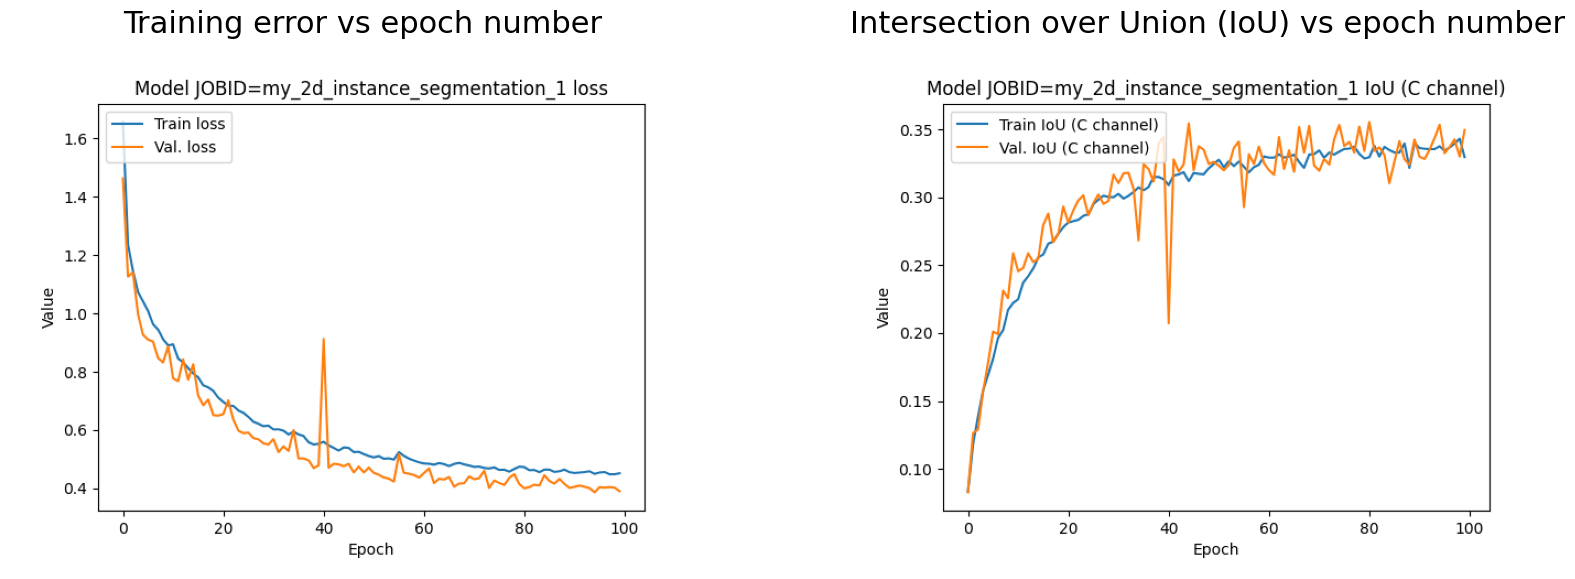

In [11]:
#@markdown ##Play the cell to show a plot of training error vs. epoch number and IoU vs epoch number
#@markdown #### Each channel that composes the instance representation has its own chart. Here, only the first plot found in the 'chart' result folder is shown, but there may be more depending on the selected representation.
import matplotlib.pyplot as plt

plot_dir = output_path + '/'+job_name+'/results/'+job_name+'_1/charts/'
plots = sorted(next(os.walk(plot_dir))[2])

loss_file = [x for x in plots if "loss" in x][0]
loss_plot = imread( os.path.join(plot_dir, loss_file))

first_channel_file = [x for x in plots if "loss" not in x][0]
iou_plot = imread( os.path.join(plot_dir, first_channel_file))

fig = plt.figure( figsize = (20,10))
ax1 = plt.subplot( 1, 2, 1 )
_ = plt.imshow( loss_plot )
_ = plt.axis('off')
ax1.set_title( 'Training error vs epoch number', fontdict = {'fontsize':22})

ax2 = plt.subplot( 1, 2, 2 )
_ = plt.imshow( iou_plot )
_ = plt.axis('off')
_= ax2.set_title( 'Intersection over Union (IoU) vs epoch number', fontdict = {'fontsize':22})

## **Visualize instance segmentation results (from the test set)**


## **Visualize instance segmentation results (from the test set)**

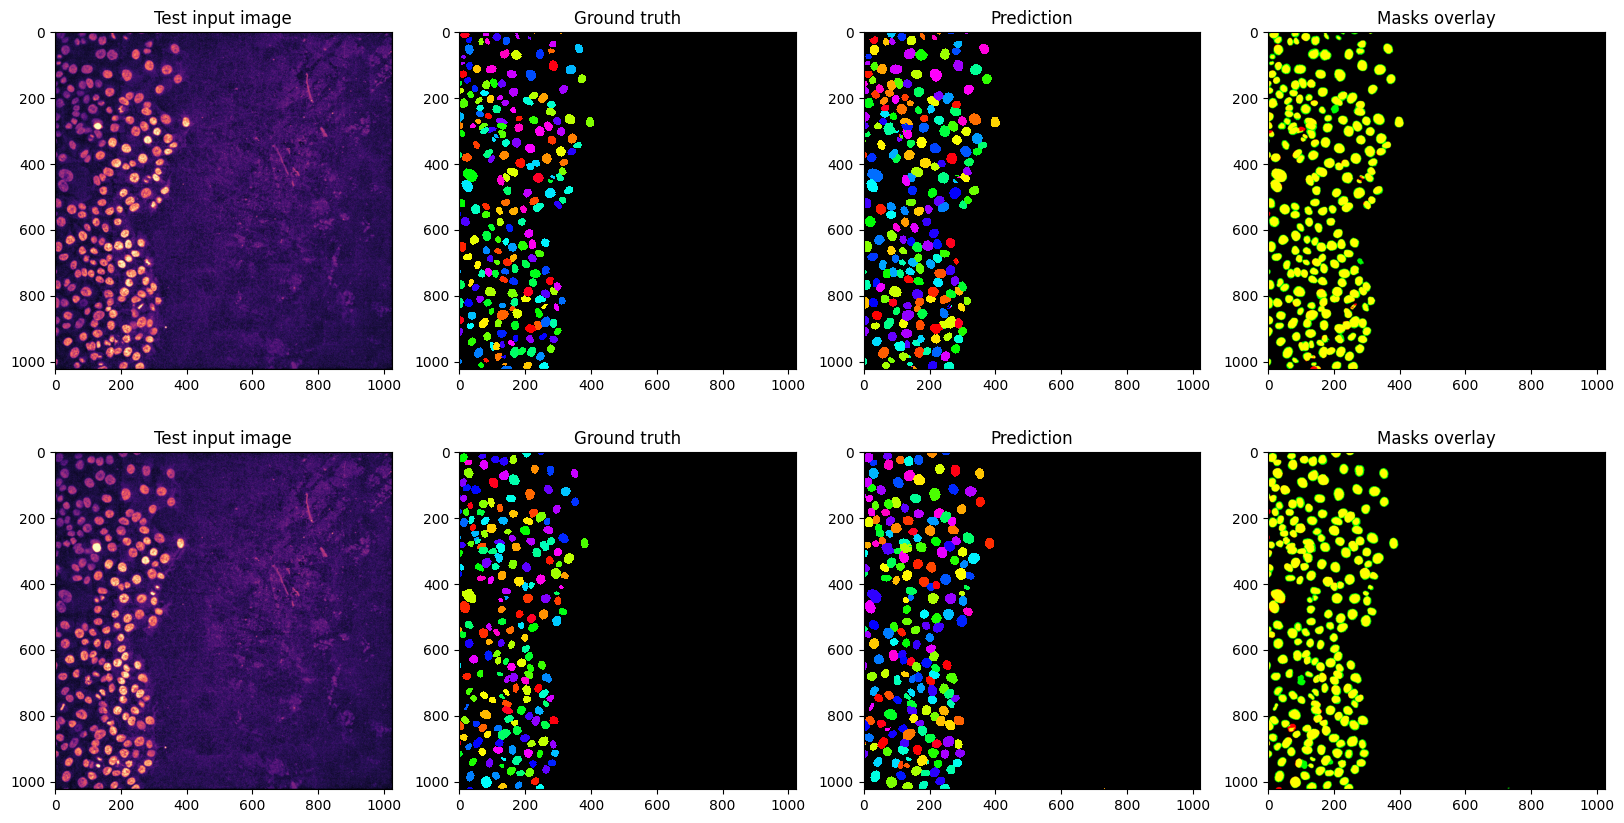

In [12]:
final_results = os.path.join(output_path, job_name, 'results', job_name + "_1")
if biapy_config['TEST']['FULL_IMG']:
    instance_results = os.path.join(final_results, "full_image_instances")
else:
    instance_results = os.path.join(final_results, "per_image_instances")

#@markdown ##Play to visualize some results from the test set
#@markdown The current model will be applied to some test images and results will be shown displaying:
#@markdown 1. The original **Test input image**.
#@markdown 2. Its corresponding **Ground truth** labels.
#@markdown 3. The model **Prediction** labels.
#@markdown 4. The **Masks overlay** (true positive pixels in yellow, false negative pixels in red, and false positive pixels in green).

from IPython.display import Markdown as md
md("After this last step, the resulting images should be placed in {}".format(final_results))
# Show a few examples to check that they have been stored correctly
%matplotlib inline
import matplotlib
import numpy as np
from numpy.random import randint, seed
from matplotlib import pyplot as plt

ids_pred = sorted(next(os.walk(instance_results))[2])
ids_input = sorted(next(os.walk(test_data_path))[2])
ids_gt = sorted(next(os.walk(test_data_gt_path))[2])

# create random color map
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gist_rainbow(vals))
cmap.colors[0] = [0., 0., 0., 1.] # set background to black

samples_to_show = min(len(ids_input), 3)
chosen_images = np.random.choice(len(ids_input), samples_to_show, replace=False)
seed(1)

test_samples = []
test_sample_preds = []
test_sample_gt = []

for i in range(len(chosen_images)):
    aux = imread(os.path.join(test_data_path, ids_input[chosen_images[i]]))
    test_samples.append(aux)

    aux = imread(os.path.join(instance_results, ids_pred[chosen_images[i]])).astype(np.uint16)
    test_sample_preds.append(aux)

    aux = imread(os.path.join(test_data_gt_path, ids_gt[chosen_images[i]])).astype(np.uint16)
    test_sample_gt.append(aux)

# Show predicted images
plt.figure(figsize=(20,10))
index = 1
for j in range(samples_to_show):
    plt.subplot(samples_to_show, 4, index)
    plt.title("Test input image")
    plt.imshow(test_samples[j], cmap='magma', vmin=np.percentile(test_samples[j],0.1),vmax=np.percentile(test_samples[j],99.9))

    index = index + 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Ground truth")
    plt.imshow(test_sample_gt[j],  cmap=cmap, interpolation='nearest')

    index = index + 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Prediction")
    plt.imshow(test_sample_preds[j], cmap=cmap, interpolation='nearest')

    index = index + 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Masks overlay")
    b = np.zeros( test_sample_gt[j].shape )
    overlay = np.dstack( (test_sample_gt[j]>0, test_sample_preds[j]>0, b ))
    plt.imshow( overlay )

    index = index + 1
plt.show()


## **Inference**

In [21]:
yaml_file = 'stardist/my_2d_instance_segmentation.yaml'
checkpoint_file = '/home/mpaul2/stardist/output/my_2d_instance_segmentation/checkpoints/my_2d_instance_segmentation_1-checkpoint-best.pth'
test_data_path = 'stardist/data/test/raw'
test_data_gt_path = 'stardist/data/test/label'
load_gt = True 
output_path = 'stardist/inference' 

In [22]:
#@markdown ##Play to run the model
import os
import errno

#os.chdir('/content/')

# Edit previous configuration file if it exists to load the checkpoint model
if os.path.exists( yaml_file ):
    import yaml
    with open( yaml_file, 'r') as stream:
        try:
            biapy_config = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
else:
    raise ValueError(f" Configuration file not found: {yaml_file}")

# Check folders before modifying the .yaml file
if not os.path.exists(test_data_path):
    raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), test_data_path)
ids = sorted(next(os.walk(test_data_path))[2])

if len(ids) == 0:
    raise ValueError("No images found in dir {}".format(test_data_path))

biapy_config['DATA']['TEST']['PATH'] = test_data_path
if load_gt == True:
    biapy_config['DATA']['TEST']['GT_PATH'] = test_data_gt_path
else:
    biapy_config['DATA']['TEST']['GT_PATH'] = "/"

biapy_config['DATA']['TEST']['LOAD_GT'] = load_gt
biapy_config['TRAIN']['ENABLE'] = False
biapy_config['TEST']['ENABLE'] = True


if not os.path.exists(checkpoint_file):
    raise ValueError("Checkpoint file not found: {}".format(checkpoint_file))
biapy_config['PATHS'] = {}
biapy_config['PATHS']['CHECKPOINT_FILE']= checkpoint_file
biapy_config['MODEL']['LOAD_CHECKPOINT']= True

# save file
with open( yaml_file, 'w') as outfile:
    yaml.dump(biapy_config, outfile, default_flow_style=False)

print( "Inference configuration finished.")

job_name = os.path.splitext(yaml_file)[0].split('/')[-1]

# Run the code
biapy = BiaPy(yaml_file, result_dir=output_path, name=job_name, run_id=1, gpu="0")
biapy.run_job()


[14:37:46.031121] Inference configuration finished.
[14:37:46.031595] Date     : 2026-09-01 14:37:46
[14:37:46.031640] Arguments: Namespace(config='stardist/my_2d_instance_segmentation.yaml', result_dir='stardist/inference', name='my_2d_instance_segmentation', run_id=1, gpu='0', world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
[14:37:46.031656] Job      : my_2d_instance_segmentation_1
[14:37:46.031670] BiaPy    : 3.6.8
[14:37:46.031683] Python   : 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]
[14:37:46.031699] PyTorch  : 2.5.1
[14:37:46.036205] The following changes were made in order to adapt the input configuration:
[14:37:46.038601] Not using distributed mode
[14:37:46.040923] Configuration details:
[14:37:46.040958] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0

[14:37:46.485214] ### MERGE-OV-CROP ###
[14:37:46.485268] Merging (36, 256, 256, 2) images into (1, 1024, 1024, 2) with overlapping . . .
[14:37:46.485283] Minimum overlap selected: (0, 0)
[14:37:46.485297] Padding: (32, 32)
[14:37:46.486722] Real overlapping (%): (0.13020833333333334, 0.13020833333333334)
[14:37:46.486759] Real overlapping (pixels): (25.0, 25.0)
[14:37:46.486773] (6, 6) patches per (x,y) axis
[14:37:46.509677] **** New data shape is: (1, 1024, 1024, 2)
[14:37:46.509728] ### END MERGE-OV-CROP ###
[14:37:46.509764] ### MERGE-OV-CROP ###
[14:37:46.509780] Merging (36, 256, 256, 1) images into (1, 1024, 1024, 1) with overlapping . . .
[14:37:46.509794] Minimum overlap selected: (0, 0)
[14:37:46.509807] Padding: (32, 32)
[14:37:46.510346] Real overlapping (%): (0.13020833333333334, 0.13020833333333334)
[14:37:46.510376] Real overlapping (pixels): (25.0, 25.0)
[14:37:46.510389] (6, 6) patches per (x,y) axis
[14:37:46.515560] **** New data shape is: (1, 1024, 1024, 1)
[14:37

[14:37:46.601985] Creating instances with watershed . . .
[14:37:46.666233] Thresholds used: {'seed': [0.47107887268066406, 0.4096572995185852], 'growth_mask': [0.23553943634033203]}
[14:37:46.707382] Saving (1, 1, 1024, 1024, 1) data as .tif in folder: stardist/inference/my_2d_instance_segmentation/results/my_2d_instance_segmentation_1/per_image_instances


[14:37:46.715587] Calculating matching stats . . .
[14:37:46.715673] Its respective image seems to be: stardist/data/test/label/cell migration R1 - Position 58_XY1562686154_Z0_T00_C1-image76.tif
[14:37:47.129897] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': np.int64(15), 'tp': np.int64(203), 'fn': np.int64(6), 'precision': np.float64(0.9311926605504587), 'recall': np.float64(0.9712918660287081), 'accuracy': np.float64(0.90625), 'f1': np.float64(0.9508196721311475), 'n_true': 209, 'n_pred': 218, 'mean_true_score': np.float32(0.7242198), 'mean_matched_score': np.float64(0.7456253126924262), 'panoptic_quality': np.float64(0.708955215346897)}
[14:37:47.133233] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': np.int64(17), 'tp': np.int64(201), 'fn': np.int64(8), 'precision': np.float64(0.9220183486238532), 'recall': np.float64(0.9617224880382775), 'accuracy': np.float64(0.8893805309734514), 'f1': np.float64(0.9414519906323185), 'n_true': 209, 'n_pred': 218, 'mean_tru

[14:37:47.446529] ### MERGE-OV-CROP ###
[14:37:47.446600] Merging (36, 256, 256, 2) images into (1, 1024, 1024, 2) with overlapping . . .
[14:37:47.446617] Minimum overlap selected: (0, 0)
[14:37:47.446630] Padding: (32, 32)
[14:37:47.448876] Real overlapping (%): (0.13020833333333334, 0.13020833333333334)
[14:37:47.448921] Real overlapping (pixels): (25.0, 25.0)
[14:37:47.448936] (6, 6) patches per (x,y) axis
[14:37:47.475835] **** New data shape is: (1, 1024, 1024, 2)
[14:37:47.475917] ### END MERGE-OV-CROP ###
[14:37:47.475959] ### MERGE-OV-CROP ###
[14:37:47.475976] Merging (36, 256, 256, 1) images into (1, 1024, 1024, 1) with overlapping . . .
[14:37:47.475991] Minimum overlap selected: (0, 0)
[14:37:47.476004] Padding: (32, 32)
[14:37:47.476910] Real overlapping (%): (0.13020833333333334, 0.13020833333333334)
[14:37:47.476945] Real overlapping (pixels): (25.0, 25.0)
[14:37:47.476957] (6, 6) patches per (x,y) axis
[14:37:47.482575] **** New data shape is: (1, 1024, 1024, 1)
[14:37

[14:37:47.583841] Creating instances with watershed . . .
[14:37:47.652098] Thresholds used: {'seed': [0.46717357635498047, 0.4102773070335388], 'growth_mask': [0.23358678817749023]}
[14:37:47.696872] Saving (1, 1, 1024, 1024, 1) data as .tif in folder: stardist/inference/my_2d_instance_segmentation/results/my_2d_instance_segmentation_1/per_image_instances


[14:37:47.705676] Calculating matching stats . . .
[14:37:47.705754] Its respective image seems to be: stardist/data/test/label/cell migration R1 - Position 58_XY1562686154_Z0_T00_C1-image86.tif
[14:37:48.105561] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': np.int64(39), 'tp': np.int64(220), 'fn': np.int64(6), 'precision': np.float64(0.8494208494208494), 'recall': np.float64(0.9734513274336283), 'accuracy': np.float64(0.8301886792452831), 'f1': np.float64(0.9072164948453608), 'n_true': 226, 'n_pred': 259, 'mean_true_score': np.float32(0.72497183), 'mean_matched_score': np.float64(0.7447437633167614), 'panoptic_quality': np.float64(0.6756438265141752)}
[14:37:48.109328] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': np.int64(47), 'tp': np.int64(212), 'fn': np.int64(14), 'precision': np.float64(0.8185328185328186), 'recall': np.float64(0.9380530973451328), 'accuracy': np.float64(0.7765567765567766), 'f1': np.float64(0.8742268041237113), 'n_true': 226, 'n_pred': 